# Student Performance Prediction – EDA & Linear Regression

In [ ]:
#importing major libraries
import pandas as pd
import numpy as np
#importing data visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [ ]:
#reading the dataset
df=pd.read_csv('/content/Student_Performance.csv')

In [ ]:
#inspecting the shape
print(f'The student performance dataset contains {df.shape[0]} rows and {df.shape[1]} columns.')

The student performance dataset contains 10000 rows and 6 columns.


In [ ]:
#inspecting the basic structure and datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [ ]:
#checking if there are any duplicate records
df.duplicated().sum()

np.int64(127)

In [ ]:
# dropping duplicate records
df=df.drop_duplicates()

In [ ]:
#checking for missing records
df.isna().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


In [ ]:
#checking unique values in all the columns
for col in df.columns:
  print(f'{col} \n {df[col].unique()}')

Hours Studied 
 [7 4 8 5 3 6 2 1 9]
Previous Scores 
 [99 82 51 52 75 78 73 45 77 89 91 79 47 72 83 54 96 74 85 61 62 84 94 90
 44 70 67 97 59 55 68 63 46 76 43 81 93 98 48 92 64 88 60 87 40 69 80 95
 49 50 53 71 56 58 66 65 57 41 42 86]
Extracurricular Activities 
 ['Yes' 'No']
Sleep Hours 
 [9 4 7 5 8 6]
Sample Question Papers Practiced 
 [1 2 5 6 0 8 3 4 9 7]
Performance Index 
 [ 91.  65.  45.  36.  66.  61.  63.  42.  69.  84.  73.  27.  33.  68.
  43.  67.  70.  30.  71.  85.  57.  35.  49.  83.  74.  39.  58.  47.
  60.  32.  64.  54.  17.  53.  75.  52.  78.  38.  98.  87.  41.  81.
  15.  88.  95.  29.  21.  76.  25.  34.  50.  56.  82.  23.  46.  92.
  77.  86.  44.  94.  40. 100.  31.  26.  18.  51.  72.  16.  28.  89.
  48.  37.  62.  59.  19.  79.  22.  10.  90.  80.  24.  20.  96.  55.
  97.  12.  93.  14.  99.  11.  13.]


**Insights**
- After cleaning, **9,873 rows** remain, which is plenty for a model with five features.
- No other cleaning is needed: no missing values and no impossible values.

## Exploratory Data Analysis

In [ ]:
#setting color palette
sns.set_palette("Blues_d")

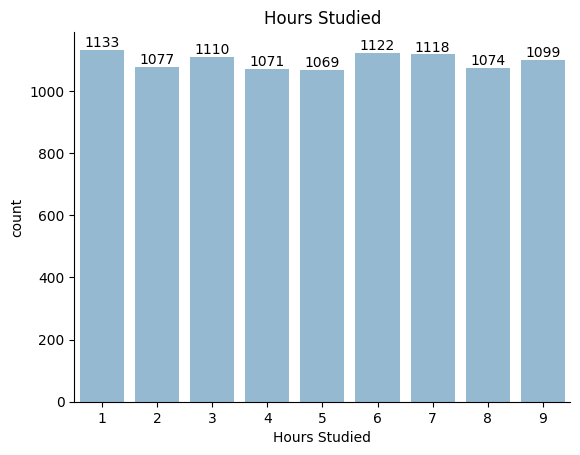

In [ ]:
#hours studied
ax=sns.countplot(data=df,x='Hours Studied')
plt.title('Hours Studied')
plt.gca().spines[['top','right']].set_visible(False)
for p in ax.patches:
  ax.text(p.get_x()+p.get_width()/2,p.get_height(),int(p.get_height()),ha='center',va='bottom')
plt.show()

**Insights** – Students are spread **almost evenly across 1 to 9 study hours** (about 1,070 to 1,130 students at each level). No study-time group dominates, so the model sees every level equally often.

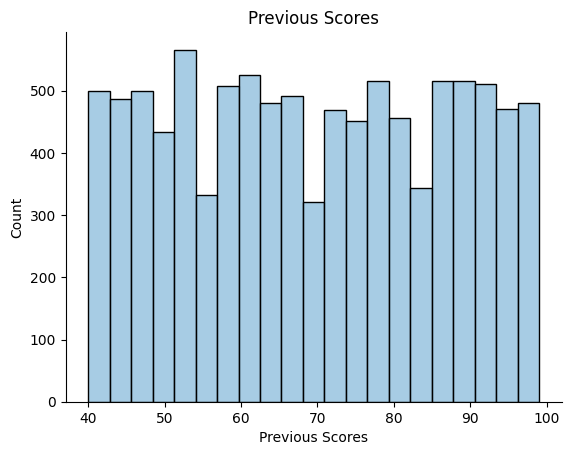

In [ ]:
#previous scores
sns.histplot(data=df,x='Previous Scores')
plt.title('Previous Scores')
plt.gca().spines[['top','right']].set_visible(False)

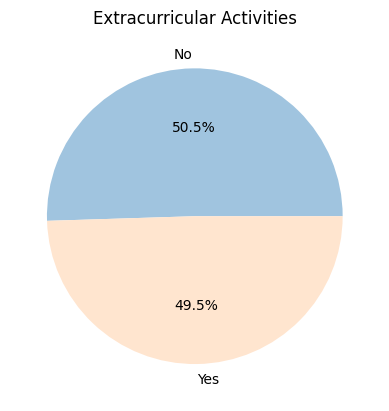

In [ ]:
#extra-curricular activities
plt.pie(df['Extracurricular Activities'].value_counts(),labels=df['Extracurricular Activities'].value_counts().index,autopct='%1.1f%%',colors=['#A0C4DF','#FFE5CF'])
plt.title('Extracurricular Activities')
plt.gca().spines[['top','right']].set_visible(False)

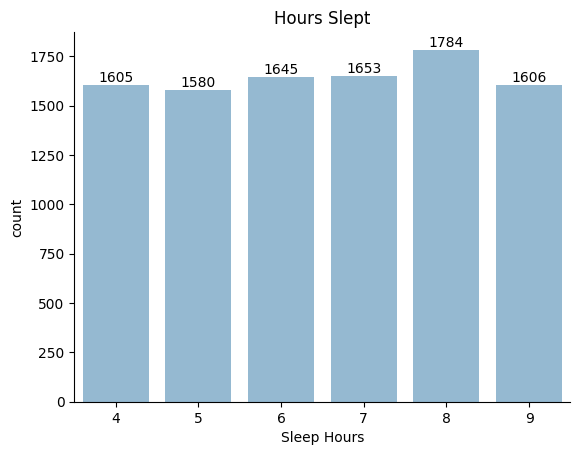

In [ ]:
#hours slept
ax=sns.countplot(data=df,x='Sleep Hours')
plt.title('Hours Slept')
for p in ax.patches:
  ax.text(p.get_x()+p.get_width()/2,p.get_height(),int(p.get_height()),ha='center',va='bottom')
plt.gca().spines[['top','right']].set_visible(False)

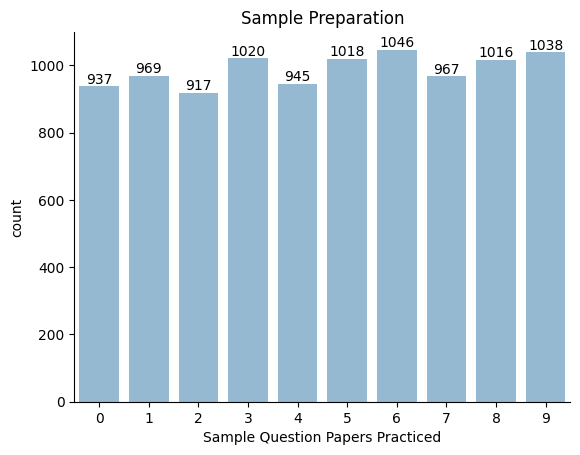

In [ ]:
#sample paper solved
ax=sns.countplot(data=df,x='Sample Question Papers Practiced')
plt.title('Sample Preparation')
for p in ax.patches:
  ax.text(p.get_x()+p.get_width()/2,p.get_height(),int(p.get_height()),ha='center',va='bottom')
plt.gca().spines[['top','right']].set_visible(False)

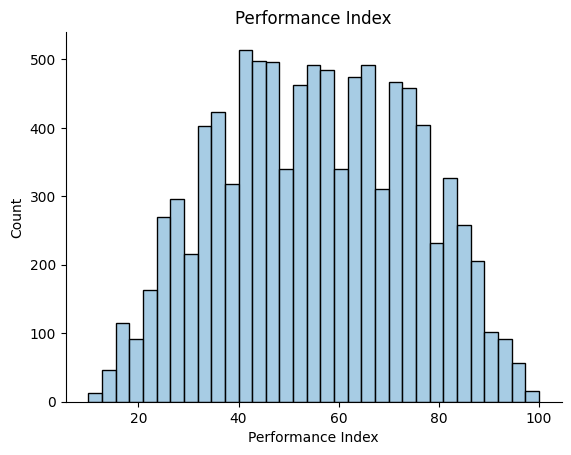

In [ ]:
#performance index
sns.histplot(data=df,x='Performance Index')
plt.title('Performance Index')
plt.gca().spines[['top','right']].set_visible(False)


**Insights** – The target is **roughly bell-shaped**: most students score between about **30 and 80**, and very few score below 20 or above 90. The model therefore has the most examples in the middle of the range, and the extremes are predicted with less data behind them.

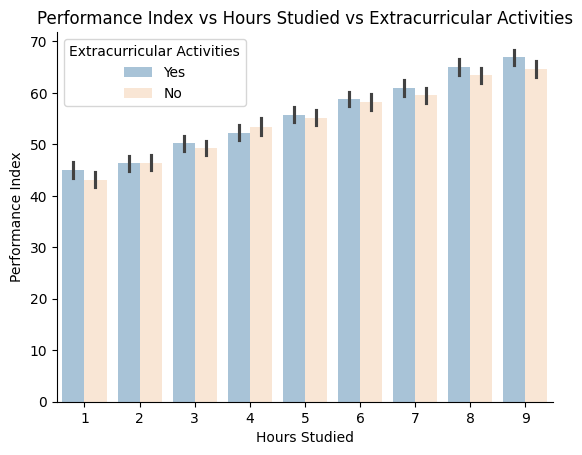

In [ ]:
#hours studied vs performance index vs extra curricular activities
sns.barplot(data=df,x='Hours Studied',y='Performance Index',hue='Extracurricular Activities',palette=['#A0C4DF','#FFE5CF'])
plt.title('Performance Index vs Hours Studied vs Extracurricular Activities')
plt.gca().spines[['top','right']].set_visible(False)

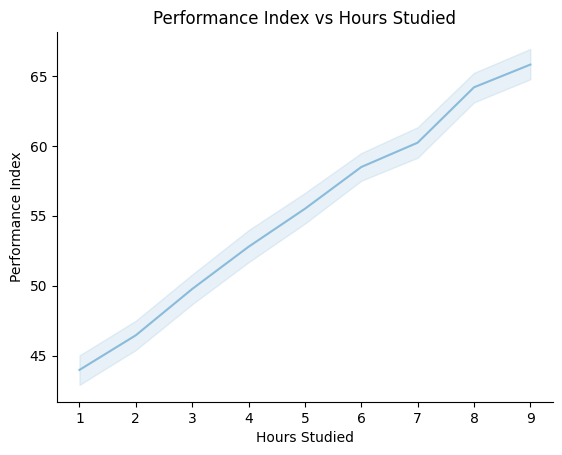

In [ ]:
#relationship between hours studied and performance index
sns.lineplot(data=df,x='Hours Studied',y='Performance Index')
plt.title('Performance Index vs Hours Studied')
plt.gca().spines[['top','right']].set_visible(False)


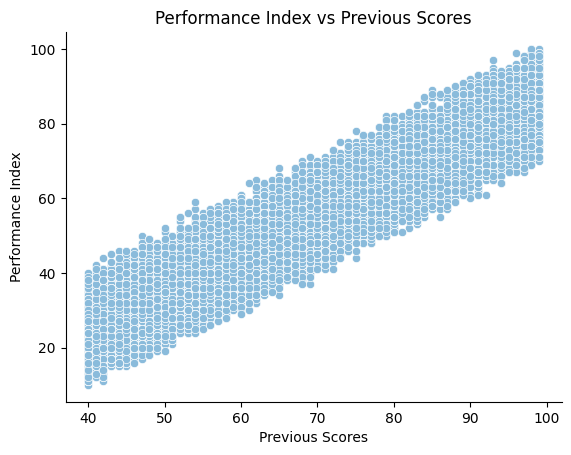

In [ ]:
#relationship between previous scores and performance index
sns.scatterplot(data=df,x='Previous Scores',y='Performance Index')
plt.title('Performance Index vs Previous Scores')
plt.gca().spines[['top','right']].set_visible(False)


**Insights**
- This is a **strong, straight-line relationship**: students with a previous score near 40 mostly score between about 10 and 40, while those near 99 score between about 70 and 100.
- The band has about the **same vertical width everywhere (roughly 30 points)**. For the same previous score, other habits such as study hours still move performance by up to about 30 points.
- A straight band of constant width is exactly the pattern **Linear Regression** handles well, so this model is a good choice.

## Machine Learning


In [ ]:
#importing major libraries for linear regression model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [ ]:
df.head(5)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [ ]:
#encoding extracurricular activities (No=0, Yes=1)
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'No':0,'Yes':1})

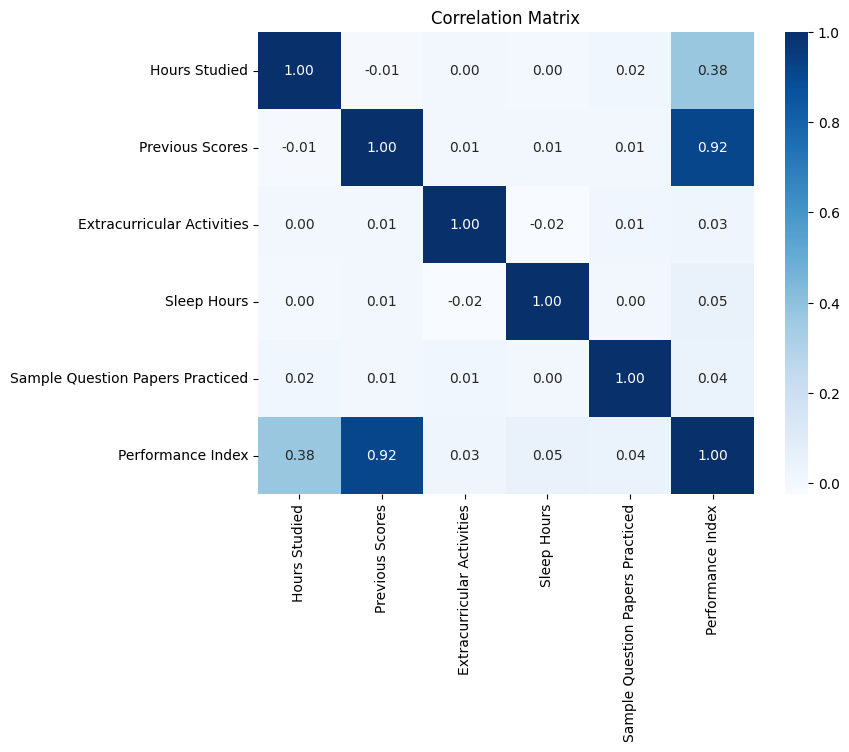

,Performance Index
Performance Index,1.000000
Previous Scores,0.915135
Hours Studied,0.375332
Sleep Hours,0.050352
Sample Question Papers Practiced,0.043436
Extracurricular Activities,0.026075


In [ ]:
#correlation of every feature with the target
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),annot=True,fmt='.2f',cmap='Blues')
plt.title('Correlation Matrix')
plt.show()
df.corr()['Performance Index'].sort_values(ascending=False)

In [ ]:
#defining features and target variable
x=df.drop('Performance Index',axis=1)
y=df['Performance Index']

In [ ]:
#train test split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
#fitting the model
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
#prediction
y_pred=model.predict(x_test)

In [ ]:
#evaluating the model
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)


In [ ]:
#displaying evaluation result
print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'R-squared: {r2}')
print(f'Model_coeff: {model.coef_}')
print(f'Model_intercept: {model.intercept_}')

Mean Absolute Error: 1.6469703984255573
Mean Squared Error: 4.305900938538479
Root Mean Squared Error: 2.0750664901488047
R-squared: 0.9884301209927054
Model_coeff: [2.8510219  1.01843034 0.57382297 0.47207329 0.18870366]
Model_intercept: -33.981324496440635


**Insights – model performance** *(from the original run: MAE 1.65, MSE 4.31, RMSE 2.08, R² 0.988)*
- **MAE ≈ 1.65:** on a 10–100 scale, predictions are off by only about **1.6 points** on average.
- **RMSE (2.08) is only slightly higher than MAE (1.65)**, so there are no large outlier errors. Mistakes are small and consistent.
- **R² ≈ 0.988:** the model explains about **98.8% of the variation** in Performance Index.

In [ ]:
#training vs testing score- a large gap would mean overfitting
print(f'Train R2: {model.score(x_train,y_train):.4f}')
print(f'Test  R2: {model.score(x_test,y_test):.4f}')

Train R2: 0.9887
Test  R2: 0.9884


In [ ]:
#comparing actual vs prediction result
comparison=pd.DataFrame({'Actual':y_test,'Predicted':y_pred})
comparison.head(10)

,Actual,Predicted
6099,47.0,46.480013
106,76.0,80.285379
9265,62.0,61.065188
4707,23.0,22.706315
2155,76.0,74.836868
6594,83.0,84.194968
9438,60.0,61.993141
8905,51.0,50.337443
2012,38.0,38.898681
568,58.0,55.753202


In [ ]:
#predicting performance index for a student: hours studied=9, previous scores=95, extracurricular=0 (No), sleep hours=7, sample papers=2
pred=np.array([[9,95,0,7,2]])
perf_pred=model.predict(pred)
print(f'The predicted performance index is {perf_pred[0]}')

The predicted performance index is 92.11067558274051


**Insights**
- A student who studies 9 hours, scored 95 before, sleeps 7 hours and practiced 2 papers is predicted at about **92.1**, which is realistic for a strong student.
- Keep inputs inside the training ranges (hours 1–9, previous scores 40–99). Predictions outside them are extrapolation and less reliable.

In [ ]:
#checking model stability by cross validating the scores
from sklearn.model_selection import cross_val_score
print(cross_val_score(model, x, y, cv=5, scoring='r2'))

[0.98883679 0.98820297 0.98904465 0.9890682  0.98815434]


**Insights**
- The five R² scores from the original run were all between **0.988 and 0.989** (mean ≈ **0.9887**).
- Almost no spread means the model performs equally well on every part of the data, so the result is **not luck from one lucky split**.